
# Part 1: Starting from High Explainability

Decision Trees and GAM's might be a natural starting place for models where explainability could be critical. Insight into exactly what is driving the classifier could drive your advertising spend in future campaigns or even as this one continues. 


In [72]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from torch.utils.data import DataLoader, TensorDataset
import time
from datetime import datetime
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

RANDOM_SEED = 42

In [73]:


marketing_file = "./dataset/marketing_campaign.csv"

marketing_df = pd.read_csv("./dataset/marketing_campaign.csv", sep='\t', encoding="ascii")


In [74]:
marketing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [75]:
marketing_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [76]:
# Fill null values with median
marketing_df['Income'] = marketing_df['Income'].fillna(marketing_df['Income'].median())

In [77]:
# Dt_Customer ->datetime
marketing_df['Dt_Customer'] = pd.to_datetime(marketing_df['Dt_Customer'], format='%d-%m-%Y')

reference_date = datetime(2014, 7, 1)
marketing_df['Customer_Since_Months'] = (reference_date - marketing_df['Dt_Customer']).dt.days // 30

marketing_df.drop(columns=['Dt_Customer'], inplace=True)

In [78]:
print(marketing_df['Education'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Education'], drop_first=False)

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [79]:
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].replace({'Absurd': 'Other', 'YOLO': 'Other'})

print(marketing_df['Marital_Status'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Marital_Status'], drop_first=False)

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Other         4
Alone         3
Name: count, dtype: int64


In [80]:
marketing_df['Age'] = 2015 - marketing_df['Year_Birth']

marketing_df.drop(columns=['Year_Birth'], inplace=True)


In [81]:
irrelevant_columns = ['ID', 'NumDealsPurchases', 'Response']
marketing_df = marketing_df.drop(columns=irrelevant_columns)

In [82]:
marketing_df['AcceptedAny'] = (
    (marketing_df['AcceptedCmp1'] == 1) | 
    (marketing_df['AcceptedCmp2'] == 1) | 
    (marketing_df['AcceptedCmp3'] == 1) | 
    (marketing_df['AcceptedCmp4'] == 1) | 
    (marketing_df['AcceptedCmp5'] == 1)
).astype(int)

marketing_df.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], inplace=True)

print(marketing_df[['AcceptedAny']].value_counts())

AcceptedAny
0              1777
1               463
Name: count, dtype: int64


In [83]:
marketing_df['Education'] = marketing_df[['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD']].idxmax(axis=1)

marketing_df['Marital_Status'] = marketing_df[['Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 
                                               'Marital_Status_Divorced', 'Marital_Status_Widow', 'Marital_Status_Alone',
                                               'Marital_Status_Other']].idxmax(axis=1)
marketing_df.drop(columns=['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD',
                           'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 'Marital_Status_Divorced', 
                           'Marital_Status_Widow', 'Marital_Status_Alone', 'Marital_Status_Other'], inplace=True)

print(marketing_df[['Education', 'Marital_Status']].head())

              Education           Marital_Status
0  Education_Graduation    Marital_Status_Single
1  Education_Graduation    Marital_Status_Single
2  Education_Graduation  Marital_Status_Together
3  Education_Graduation  Marital_Status_Together
4         Education_PhD   Marital_Status_Married


In [84]:
marketing_df['Education'] = marketing_df['Education'].str.replace('Education_', '')
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].str.replace('Marital_Status_', '')

print(marketing_df[['Education', 'Marital_Status']].head())

    Education Marital_Status
0  Graduation         Single
1  Graduation         Single
2  Graduation       Together
3  Graduation       Together
4         PhD        Married


In [85]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
marketing_df['Education'] = label_enc.fit_transform(marketing_df['Education'])
marketing_df['Marital_Status'] = label_enc.fit_transform(marketing_df['Marital_Status'])

print(marketing_df[['Education', 'Marital_Status']].value_counts())

Education  Marital_Status
2          2                 433
           5                 286
           4                 252
4          2                 192
3          2                 138
2          1                 119
4          5                 117
3          5                 106
4          4                  98
0          2                  81
3          4                  75
0          5                  57
4          1                  52
3          1                  37
0          4                  37
2          6                  35
4          6                  24
0          1                  23
1          2                  20
           4                  18
           5                  14
3          6                  12
0          6                   5
4          3                   2
3          0                   1
1          1                   1
4          0                   1
2          0                   1
1          6                   1
2          3     

In [86]:
def split_data(marketing_df, method='train_val_test', k=5, val_size=0.2, test_size=0.2):
    
    X = marketing_df.drop(columns=['AcceptedAny']).values
    y = marketing_df['AcceptedAny'].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if method == 'train_val_test':
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=RANDOM_SEED, stratify=y
        )
        
        val_size_adjusted = val_size / (1 - test_size) 
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size_adjusted, random_state=RANDOM_SEED, stratify=y_train_val
        )

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

        print(f"Train: {X_train_tensor.shape[0]}, Val: {X_val_tensor.shape[0]}, Test: {X_test_tensor.shape[0]}")
        return X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor

    elif method == 'cross_val':
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
        folds = []

        for train_index, test_index in skf.split(X, y):
            X_train_fold, X_test_fold = X[train_index], X[test_index]
            y_train_fold, y_test_fold = y[train_index], y[test_index]

            X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
            X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).unsqueeze(1)

            folds.append((X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor))

        print(f"Train: {folds[0][0].shape[0]}, Test: {folds[0][2].shape[0]}")
        return folds

In [87]:

# Drop constant columns that cause NaN when StandardScaler divides by std=0
# Z_CostContact is always 3, Z_Revenue is always 11 — they carry no information
constant_cols = [col for col in marketing_df.columns if marketing_df[col].nunique() <= 1]
print(f"Dropping constant columns: {constant_cols}")
marketing_df.drop(columns=constant_cols, inplace=True)

Dropping constant columns: ['Z_CostContact', 'Z_Revenue']


Now that we are done with our data preprocessing we are getting into the first of our highly explainable models, the Decision Tree

In [88]:
# ============================================================
# Decision Tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier

feature_names = marketing_df.drop(columns=['AcceptedAny']).columns.tolist()

X = marketing_df.drop(columns=['AcceptedAny']).values
y = marketing_df['AcceptedAny'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Hyperparameter tuning: max_depth via GridSearchCV ---
param_grid = {'max_depth': [5, 7, 10, 15, 20, None]}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
end_time = time.time()

best_depth = grid_search.best_params_['max_depth']
best_dt_cv_f1 = grid_search.best_score_
print(f"Best Max Depth: {best_depth}, CV F1: {best_dt_cv_f1:.4f}")
print(f"Grid search time: {end_time - start_time:.4f}s")

print("\n{:<12} {:<10}".format("Max Depth", "CV F1"))
for mean, params in zip(grid_search.cv_results_['mean_test_score'],
                        grid_search.cv_results_['params']):
    print("{:<12} {:<10.4f}".format(str(params['max_depth']), mean))

Best Max Depth: 7, CV F1: 0.5293
Grid search time: 46.2990s

Max Depth    CV F1     
5            0.4719    
7            0.5293    
10           0.5194    
15           0.5141    
20           0.5178    
None         0.5178    


In [89]:
# --- Evaluate best DT on test set ---
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_SEED)

start_time = time.time()
dt_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()
dt_training_time = end_time - start_time

y_test_pred = dt_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"\nDecision Tree (max_depth={best_depth}) Test Results:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Training Time: {dt_training_time:.4f} seconds")


Decision Tree (max_depth=7) Test Results:
Accuracy: 0.85
F1-Score: 0.59
Precision: 0.67
Recall: 0.53
Training Time: 0.0242 seconds


Train Size: 400 | Train Error: 0.0600 | Test Error: 0.1696 | Test F1: 0.5000
Train Size: 600 | Train Error: 0.0600 | Test Error: 0.1987 | Test F1: 0.4331
Train Size: 800 | Train Error: 0.0575 | Test Error: 0.1875 | Test F1: 0.5059
Train Size: 1000 | Train Error: 0.0630 | Test Error: 0.1920 | Test F1: 0.4756
Train Size: 1200 | Train Error: 0.0808 | Test Error: 0.1719 | Test F1: 0.5549
Train Size: 1400 | Train Error: 0.0721 | Test Error: 0.1674 | Test F1: 0.4966
Train Size: 1600 | Train Error: 0.0875 | Test Error: 0.1652 | Test F1: 0.5542
Train Size: 1792 | Train Error: 0.0893 | Test Error: 0.1518 | Test F1: 0.5904


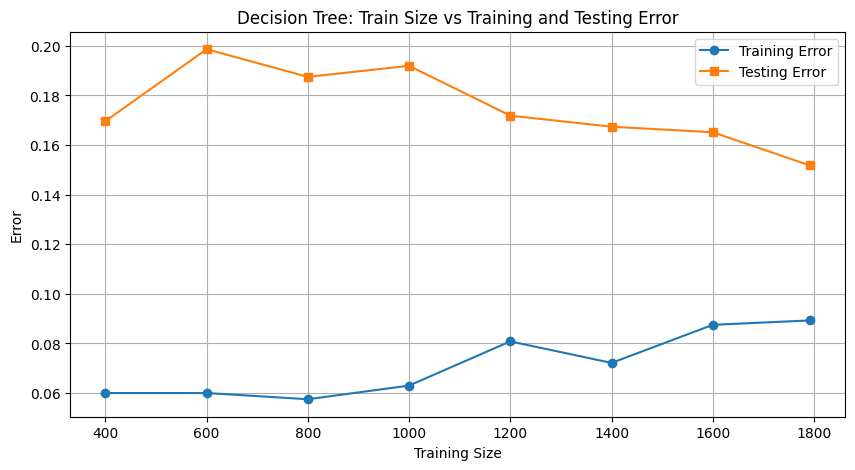

In [90]:

# --- Train size vs error ---
train_sizes = [400, 600, 800, 1000, 1200, 1400, 1600, 1792]
dt_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_SEED)
    dt_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = dt_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = dt_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    dt_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

dt_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in dt_size_results])

plt.figure(figsize=(10, 5))
plt.title("Decision Tree: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(dt_size_results_arr[:, 0], dt_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(dt_size_results_arr[:, 0], dt_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("dt_train_size_vs_error.png")
plt.show()

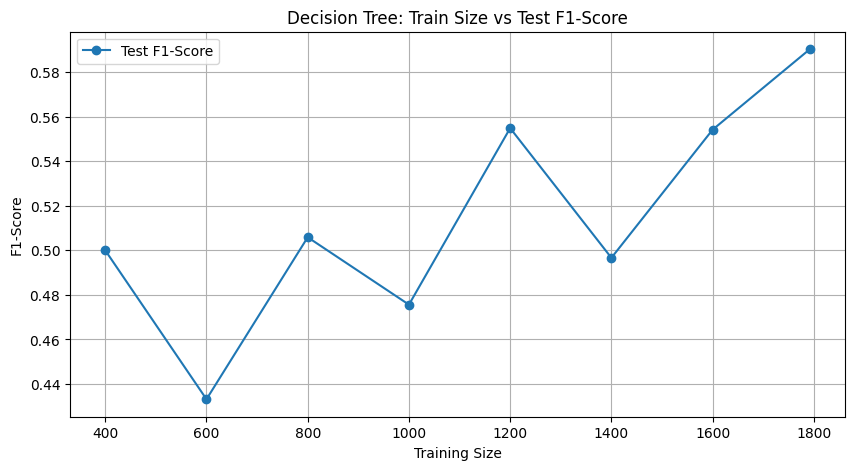

In [91]:
# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("Decision Tree: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in dt_size_results], [r['test_f1'] for r in dt_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("dt_train_size_vs_f1.png")
plt.show()

Since we have a working decision tree that we have tuned up, it is time to look into what it actually has to say about our features and dig into the explainability of the model 

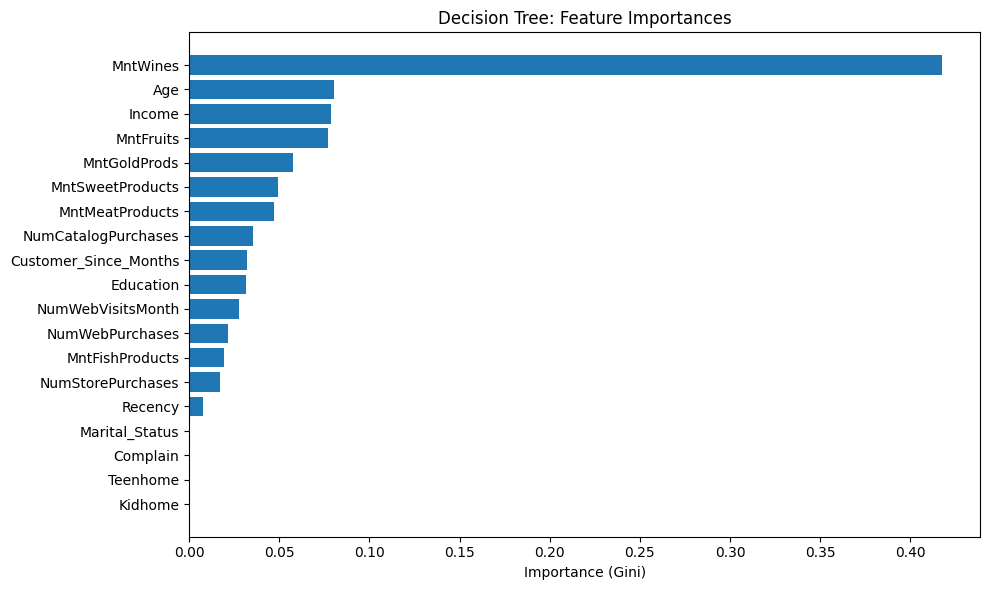


Top 10 features by importance:
  MntWines                       0.4178
  Age                            0.0801
  Income                         0.0786
  MntFruits                      0.0772
  MntGoldProds                   0.0573
  MntSweetProducts               0.0494
  MntMeatProducts                0.0469
  NumCatalogPurchases            0.0353
  Customer_Since_Months          0.0321
  Education                      0.0317


In [92]:
# --- Feature Importance ---
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.title("Decision Tree: Feature Importances")
plt.barh(range(len(sorted_features)), sorted_importances[::-1])
plt.yticks(range(len(sorted_features)), sorted_features[::-1])
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.savefig("dt_feature_importance.png")
plt.show()

print("\nTop 10 features by importance:")
for feat, imp in zip(sorted_features[:10], sorted_importances[:10]):
    print(f"  {feat:<30} {imp:.4f}")

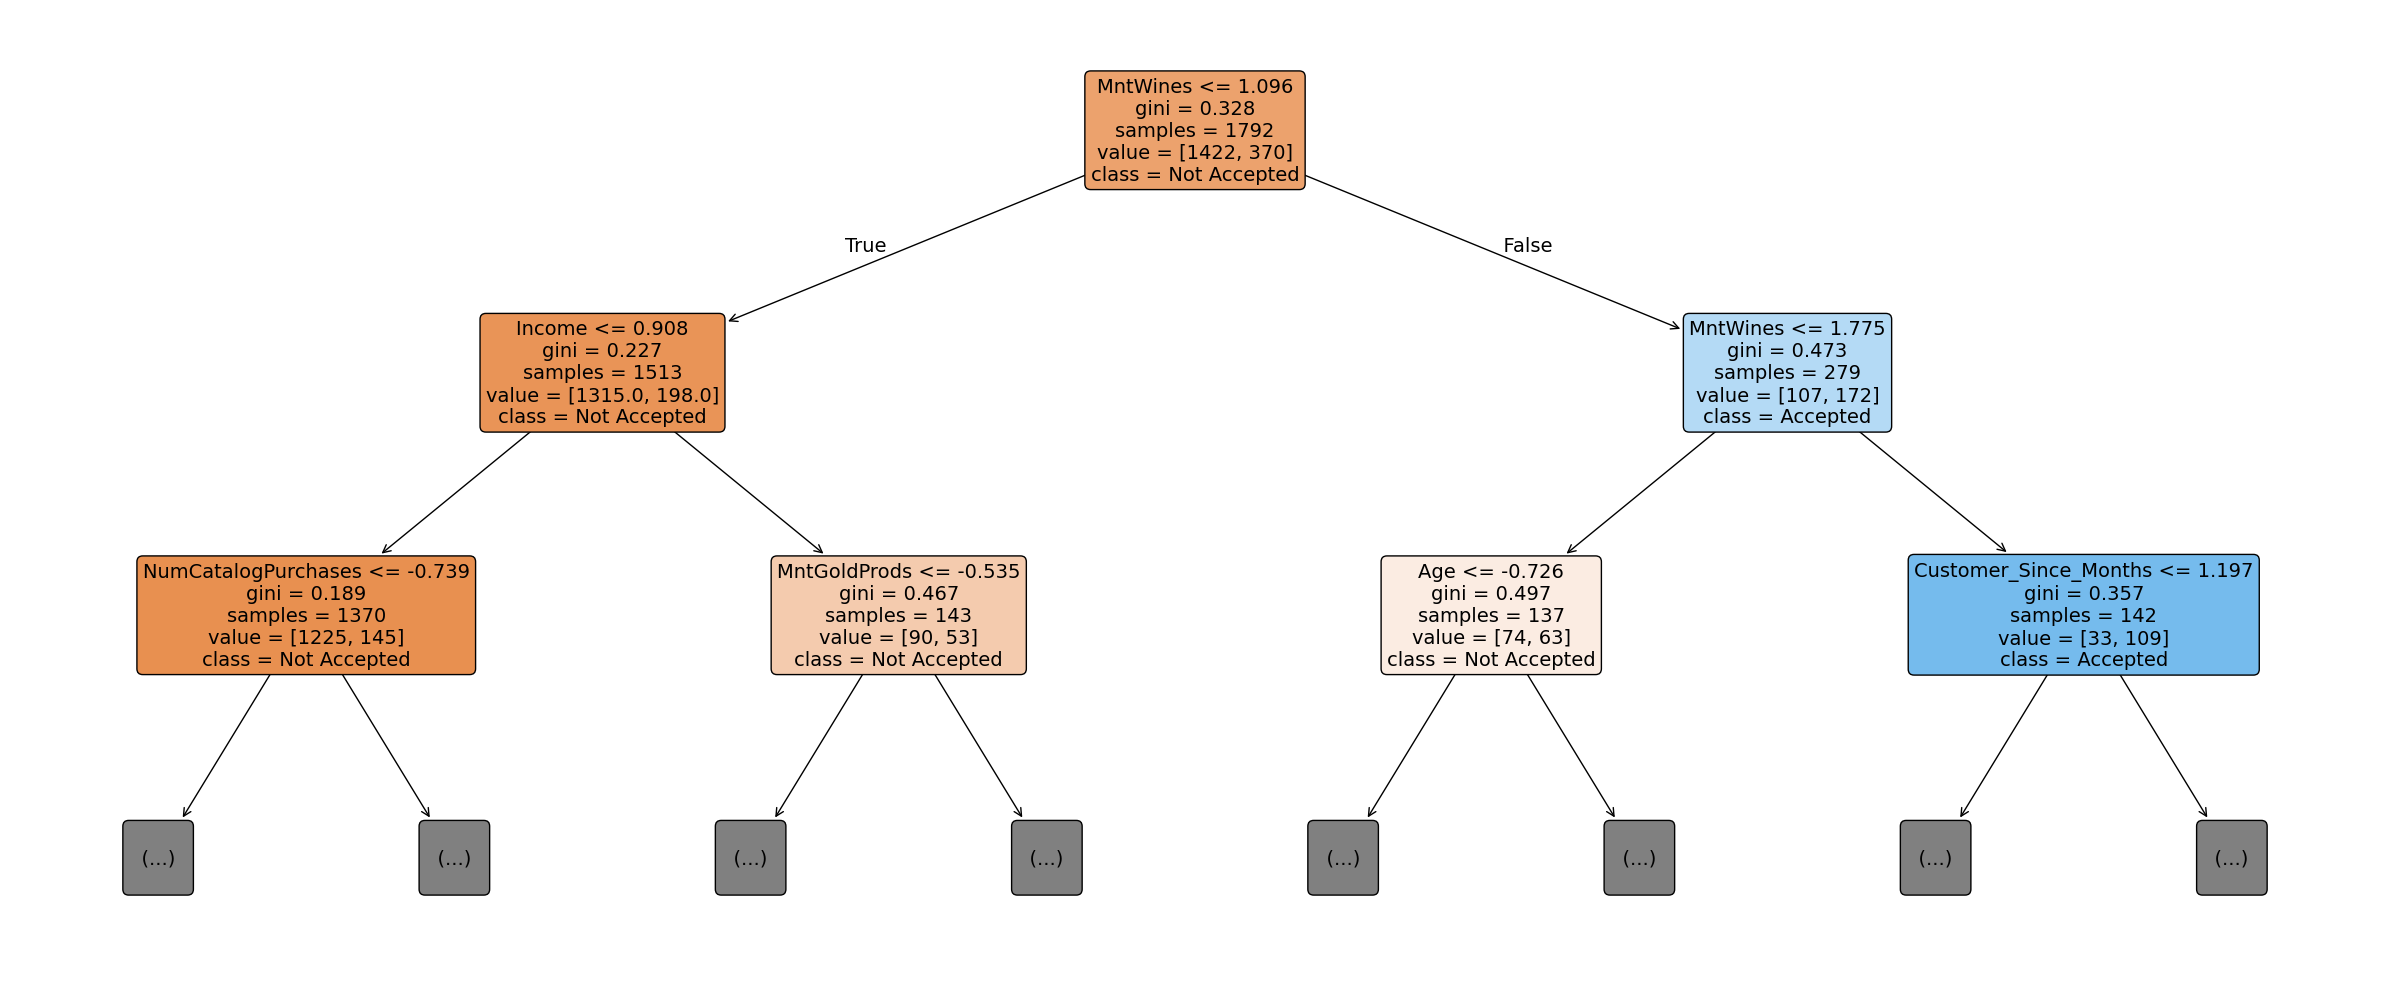

In [93]:
# --- Tree Visualization (first 2 levels for readability) ---
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 10))
plt.title(f"Decision Tree Structure (max_depth={best_depth}, showing first 2 levels)")
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['Not Accepted', 'Accepted'],
    filled=True,
    rounded=True,
    fontsize=14,
    max_depth=2
)
plt.tight_layout()
plt.savefig("dt_tree_visualization.png", dpi=150)
plt.show()

In [94]:
# --- Level-by-Level Analysis ---
from sklearn.tree import _tree
from collections import defaultdict, deque

tree_ = dt_model.tree_
node_feature = [
    feature_names[i] if i != _tree.TREE_UNDEFINED else None
    for i in tree_.feature
]

# BFS to group nodes by depth
levels = defaultdict(list)
queue = deque([(0, 0)])
while queue:
    node_id, depth = queue.popleft()
    levels[depth].append(node_id)
    left = tree_.children_left[node_id]
    right = tree_.children_right[node_id]
    if left != _tree.TREE_LEAF:
        queue.append((left, depth + 1))
        queue.append((right, depth + 1))

print(f"Tree depth: {dt_model.get_depth()} | Total nodes: {tree_.node_count}\n")
print(f"{'Level':<7} {'Nodes':<7} {'Splits':<8} {'Leaves':<8} {'Samples covered':<18} {'Features used at this level'}")
print("-" * 90)

for depth in sorted(levels.keys()):
    nodes = levels[depth]
    split_nodes = [n for n in nodes if tree_.children_left[n] != _tree.TREE_LEAF]
    leaf_nodes  = [n for n in nodes if tree_.children_left[n] == _tree.TREE_LEAF]
    total_samples = sum(tree_.n_node_samples[n] for n in nodes)

    feat_counts = defaultdict(int)
    for n in split_nodes:
        feat_counts[node_feature[n]] += 1
    feat_str = ", ".join(f"{f}×{c}" if c > 1 else f for f, c in
                         sorted(feat_counts.items(), key=lambda x: -x[1]))

    print(f"{depth:<7} {len(nodes):<7} {len(split_nodes):<8} {len(leaf_nodes):<8} {total_samples:<18} {feat_str}")

print("\n--- Split details by level ---")
for depth in sorted(levels.keys()):
    split_nodes = [n for n in levels[depth] if tree_.children_left[n] != _tree.TREE_LEAF]
    if not split_nodes:
        continue
    print(f"\nLevel {depth}:")
    for n in split_nodes:
        feat   = node_feature[n]
        thresh = tree_.threshold[n]
        samples = tree_.n_node_samples[n]
        values = tree_.value[n][0]
        majority = "Accepted" if values[1] > values[0] else "Not Accepted"
        print(f"  Node {n:>4}: {feat} <= {thresh:.3f}  "
              f"| samples={samples}  | class dist=[{int(values[0])}, {int(values[1])}]  | majority={majority}")

Tree depth: 7 | Total nodes: 127

Level   Nodes   Splits   Leaves   Samples covered    Features used at this level
------------------------------------------------------------------------------------------
0       1       1        0        1792               MntWines
1       2       2        0        1792               Income, MntWines
2       4       4        0        1792               NumCatalogPurchases, MntGoldProds, Age, Customer_Since_Months
3       8       7        1        1792               NumWebPurchases×2, NumWebVisitsMonth, MntSweetProducts, MntFruits, Education, MntFishProducts
4       14      11       3        1772               Age×2, MntFruits×2, NumStorePurchases, MntWines, MntSweetProducts, Recency, Customer_Since_Months, MntGoldProds, NumWebVisitsMonth
5       22      16       6        1755               Income×3, MntFishProducts×2, MntGoldProds×2, MntWines×2, MntMeatProducts×2, NumWebVisitsMonth, MntSweetProducts, Age, NumStorePurchases, MntFruits
6       32      

Now that we have done our basic decision tree model, lets look into another highly explainable type of model the Generalized additive model.

In [95]:
# ============================================================
# GAM (Generalized Additive Model)
# ============================================================

from pygam import LogisticGAM

X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Hyperparameter tuning: n_splines and lam via pygam gridsearch ---
n_splines_options = [ 18, 20, 22, 24]
lam_values = np.logspace(-1, 1, 3, 5)  

gam_results = []
for n in n_splines_options:
    candidate = LogisticGAM(n_splines=n)

    start_time = time.time()
    candidate.gridsearch(X_train_scaled, y_train.ravel(), lam=lam_values)
    elapsed = time.time() - start_time

    y_val_pred = candidate.predict(X_val_scaled)
    val_f1 = f1_score(y_val, y_val_pred)

    # .lam is a nested list [[val], [val], ...] after gridsearch — take the first term
    best_lam = candidate.lam[0][0]
    gam_results.append({'n_splines': n, 'lam': best_lam, 'val_f1': val_f1, 'training_time': elapsed})

print("{:<12} {:<10} {:<10} {:<15}".format("n_splines", "lam", "F1-Score", "Training Time (s)"))
for r in gam_results:
    print("{:<12} {:<10} {:<10.4f} {:<15.4f}".format(r['n_splines'], r['lam'], r['val_f1'], r['training_time']))

best_gam = max(gam_results, key=lambda x: x['val_f1'])
print(f"\nBest Config: n_splines={best_gam['n_splines']}, lam={best_gam['lam']}, Val F1: {best_gam['val_f1']:.4f}")

Train: 1344, Val: 448, Test: 448


  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 33% (1 of 3) |########                  | Elapsed Time: 0:00:02 ETA:   0:00:05
 66% (2 of 3) |#################         | Elapsed Time: 0:00:05 ETA:   0:00:02
100% (3 of 3) |##########################| Elapsed Time: 0:00:07 Time:  0:00:07
  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 33% (1 of 3) |########                  | Elapsed Time: 0:00:03 ETA:   0:00:07
 66% (2 of 3) |#################         | Elapsed Time: 0:00:06 ETA:   0:00:03
100% (3 of 3) |##########################| Elapsed Time: 0:00:12 Time:  0:00:12
  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 33% (1 of 3) |########                  | Elapsed Time: 0:00:07 ETA:   0:00:14
 66% (2 of 3) |#################         | Elapsed Time: 0:00:12 ETA:   0:00:06
100% (3 of 3) |##########################| Elapsed Time: 0:00:17 Time:  0:00:17
  0% (0 of 3) |                         

n_splines    lam        F1-Score   Training Time (s)
18           10.0       0.5490     7.9736         
20           10.0       0.5641     12.5088        
22           10.0       0.5605     17.7184        
24           10.0       0.5478     11.6340        

Best Config: n_splines=20, lam=10.0, Val F1: 0.5641


In [96]:
# --- Evaluate best GAM on test set ---
gam_model = LogisticGAM(n_splines=best_gam['n_splines'], lam=best_gam['lam'])

start_time = time.time()
gam_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()
gam_training_time = end_time - start_time

y_test_pred = gam_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"\nGAM (n_splines={best_gam['n_splines']}, lam={best_gam['lam']}) Test Results:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Training Time: {gam_training_time:.4f} seconds")


GAM (n_splines=20, lam=10.0) Test Results:
Accuracy: 0.83
F1-Score: 0.48
Precision: 0.65
Recall: 0.38
Training Time: 2.1760 seconds


Train Size: 200 | Train Error: 0.2000 | Test Error: 0.2076 | Test F1: 0.0000
Train Size: 400 | Train Error: 0.1100 | Test Error: 0.1719 | Test F1: 0.5157
Train Size: 600 | Train Error: 0.1267 | Test Error: 0.1696 | Test F1: 0.4933
Train Size: 800 | Train Error: 0.1225 | Test Error: 0.1696 | Test F1: 0.4795
Train Size: 1000 | Train Error: 0.1240 | Test Error: 0.1808 | Test F1: 0.4336
Train Size: 1200 | Train Error: 0.1333 | Test Error: 0.1763 | Test F1: 0.4552
Train Size: 1400 | Train Error: 0.1317 | Test Error: 0.1719 | Test F1: 0.4762
Train Size: 1600 | Train Error: 0.1317 | Test Error: 0.1719 | Test F1: 0.4762
Train Size: 1792 | Train Error: 0.1317 | Test Error: 0.1719 | Test F1: 0.4762


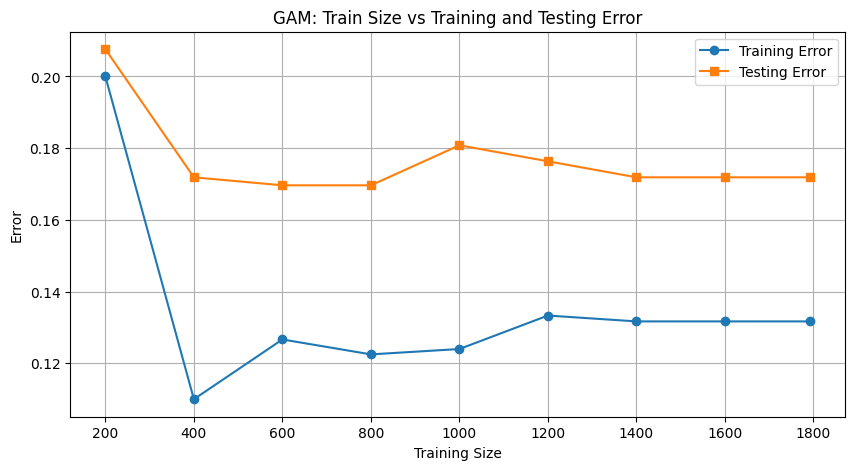

In [97]:
# --- Train size vs error ---
train_sizes = [ 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1792]
gam_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    gam_model = LogisticGAM(n_splines=best_gam['n_splines'], lam=best_gam['lam'])
    gam_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = gam_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = gam_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    gam_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

gam_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in gam_size_results])

plt.figure(figsize=(10, 5))
plt.title("GAM: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(gam_size_results_arr[:, 0], gam_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(gam_size_results_arr[:, 0], gam_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("gam_train_size_vs_error.png")
plt.show()

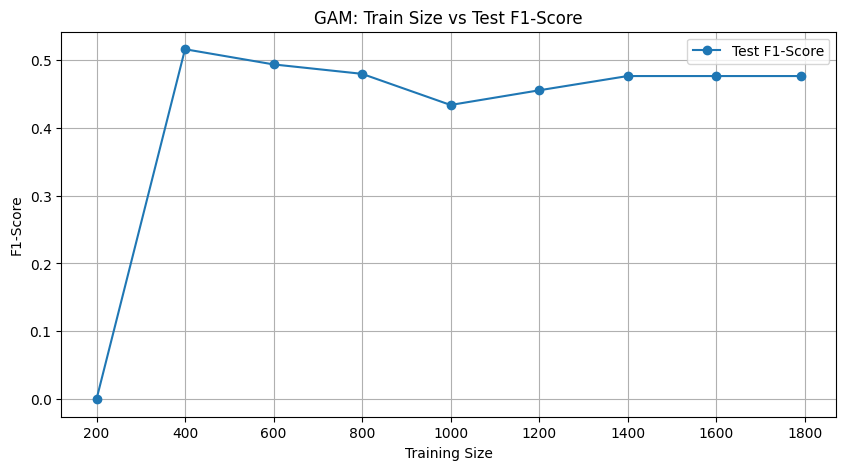

In [98]:
# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("GAM: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in gam_size_results], [r['test_f1'] for r in gam_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("gam_train_size_vs_f1.png")
plt.show()

Once again, we now have a fairly optimized GAM for the dataset, so lets do some analysis of how the various features impact the model.

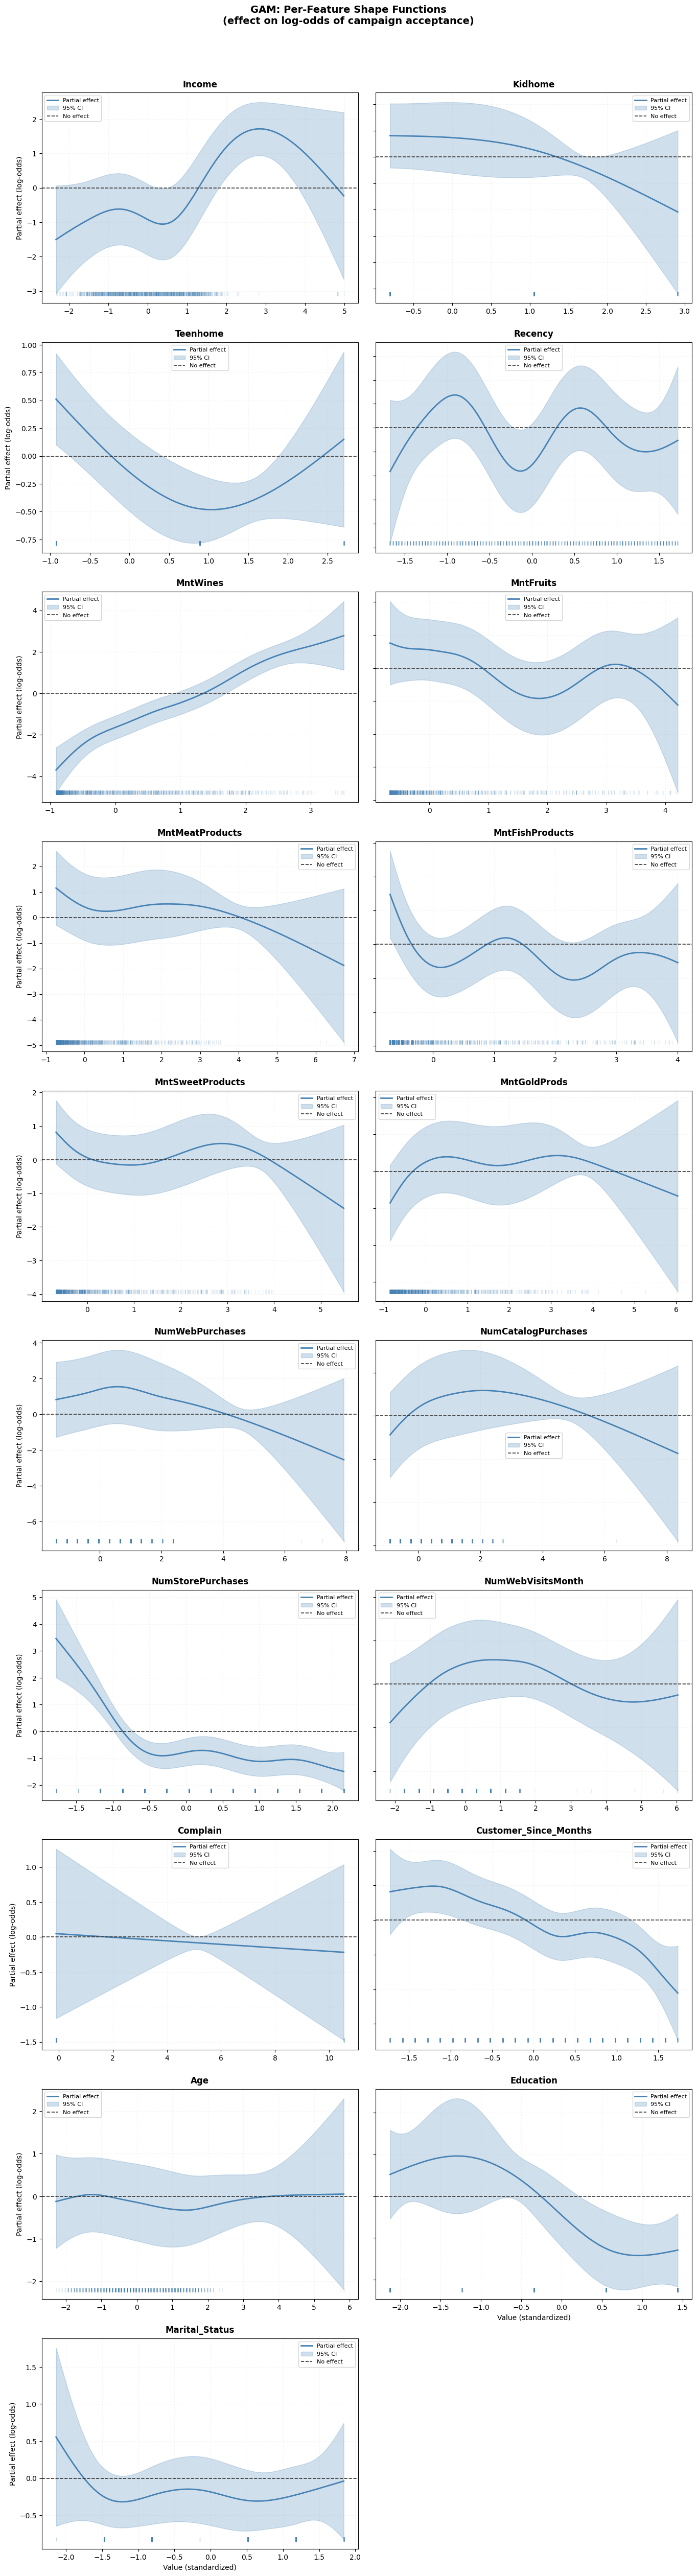

In [99]:
# --- Per-feature shape functions ---
# A GAM decomposes predictions as f(X) = β₀ + f₁(x₁) + f₂(x₂) + ... + fₙ(xₙ).
# Each shape function shows exactly how that feature shifts the log-odds of acceptance.

n_features = len(feature_names)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, feat in enumerate(feature_names):
    ax = axes[i]
    XX = gam_model.generate_X_grid(term=i)
    pdep, confi = gam_model.partial_dependence(term=i, X=XX, width=0.95)

    # Shape function line
    ax.plot(XX[:, i], pdep, color='steelblue', linewidth=2, label='Partial effect')

    # 95% confidence band
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                    alpha=0.25, color='steelblue', label='95% CI')

    # Zero reference line
    ax.axhline(0, color='#333333', linestyle='--', linewidth=1.2, label='No effect')

    # Rug plot — show where training data actually falls
    ax.plot(X_train_scaled[:, i], np.full(X_train_scaled.shape[0], confi[:, 0].min()),
            '|', color='steelblue', alpha=0.15, markersize=6)

    # Titles and labels
    ax.set_title(feat, fontsize=12, fontweight='bold', pad=8)

    # Only label y-axis on leftmost column
    if i % n_cols == 0:
        ax.set_ylabel("Partial effect (log-odds)", fontsize=10)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    # Only label x-axis on bottom row
    if i >= n_features - n_cols:
        ax.set_xlabel("Value (standardized)", fontsize=10)

    ax.grid(True, alpha=0.2, linestyle=':')
    ax.legend(fontsize=8, loc='best')

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("GAM: Per-Feature Shape Functions\n(effect on log-odds of campaign acceptance)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig("gam_shape_functions.png", dpi=150, bbox_inches='tight')
plt.show()

# Part 2: Accepting Optimizations to the Model types that improve performance and lower explainability

We are now going to look into improvements to both Decision Trees and GAM's that improve model performance but make steps away from Explainability as part of the process. This is an extraordinarily common tradeoff and is most of the time well worth the exchange. Not every application needs perfect insight into which features are most important or which ones are being used to make decisions at each step of the process. In the case of XGBoost, the model practically becomes a black box while for an Explainable Boosting Machine the model is still fundamentally white-boxed and can be understood, it is just more challenging to interpret than a standard GAM. 

In [ ]:
# ============================================================
# XGBoost (Gradient Boosted Decision Tree)
# ============================================================

from xgboost import XGBClassifier

X = marketing_df.drop(columns=['AcceptedAny']).values
y = marketing_df['AcceptedAny'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Hyperparameter tuning via GridSearchCV ---
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.125, 0.15, 0.175],
}

grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_SEED),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
end_time = time.time()

best_xgb = grid_search.best_params_
best_xgb_cv_f1 = grid_search.best_score_
print(f"Best Config: {best_xgb}, CV F1: {best_xgb_cv_f1:.4f}")
print(f"Grid search time: {end_time - start_time:.4f}s")

print("\n{:<15} {:<12} {:<15} {:<10}".format("n_estimators", "max_depth", "learning_rate", "CV F1"))
for mean, params in zip(grid_search.cv_results_['mean_test_score'],
                        grid_search.cv_results_['params']):
    print("{:<15} {:<12} {:<15} {:<10.4f}".format(
        params['n_estimators'], params['max_depth'], params['learning_rate'], mean))

Best Config: {'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 300}, CV F1: 0.6347
Grid search time: 36.2896s

n_estimators    max_depth    learning_rate   CV F1     
100             3            0.1             0.5643    
200             3            0.1             0.6024    
300             3            0.1             0.6157    
100             5            0.1             0.6133    
200             5            0.1             0.6225    
300             5            0.1             0.6215    
100             7            0.1             0.6085    
200             7            0.1             0.6089    
300             7            0.1             0.6102    
100             9            0.1             0.6183    
200             9            0.1             0.6123    
300             9            0.1             0.6191    
100             3            0.125           0.5871    
200             3            0.125           0.6189    
300             3            0.125         

In [101]:

# --- Evaluate best XGBoost on test set ---
xgb_model = XGBClassifier(
    n_estimators=best_xgb['n_estimators'],
    max_depth=best_xgb['max_depth'],
    learning_rate=best_xgb['learning_rate'],
    eval_metric='logloss',
    random_state=RANDOM_SEED
)

start_time = time.time()
xgb_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()
xgb_training_time = end_time - start_time

y_test_pred = xgb_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"\nXGBoost Test Results:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Training Time: {xgb_training_time:.4f} seconds")


XGBoost Test Results:
Accuracy: 0.86
F1-Score: 0.62
Precision: 0.74
Recall: 0.53
Training Time: 0.5882 seconds


Train Size: 400 | Train Error: 0.0000 | Test Error: 0.1763 | Test F1: 0.4837
Train Size: 600 | Train Error: 0.0000 | Test Error: 0.1674 | Test F1: 0.4526
Train Size: 800 | Train Error: 0.0000 | Test Error: 0.1540 | Test F1: 0.5306
Train Size: 1000 | Train Error: 0.0000 | Test Error: 0.1585 | Test F1: 0.5035
Train Size: 1200 | Train Error: 0.0000 | Test Error: 0.1607 | Test F1: 0.5068
Train Size: 1400 | Train Error: 0.0000 | Test Error: 0.1473 | Test F1: 0.5714
Train Size: 1600 | Train Error: 0.0000 | Test Error: 0.1317 | Test F1: 0.6194
Train Size: 1792 | Train Error: 0.0000 | Test Error: 0.1362 | Test F1: 0.6164


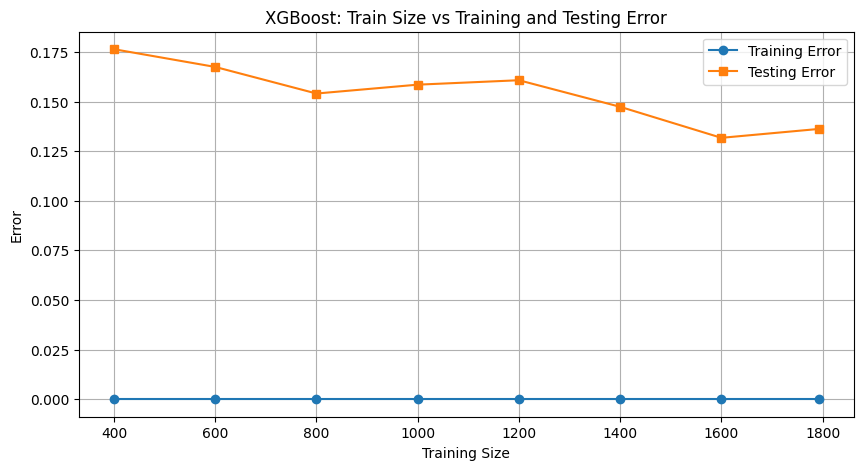

In [102]:

# --- Train size vs error ---
train_sizes = [400, 600, 800, 1000, 1200, 1400, 1600, 1792]
xgb_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    xgb_model = XGBClassifier(
        n_estimators=best_xgb['n_estimators'],
        max_depth=best_xgb['max_depth'],
        learning_rate=best_xgb['learning_rate'],
        eval_metric='logloss',
        random_state=RANDOM_SEED
    )
    xgb_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = xgb_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = xgb_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    xgb_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

xgb_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in xgb_size_results])

plt.figure(figsize=(10, 5))
plt.title("XGBoost: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(xgb_size_results_arr[:, 0], xgb_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(xgb_size_results_arr[:, 0], xgb_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("xgb_train_size_vs_error.png")
plt.show()

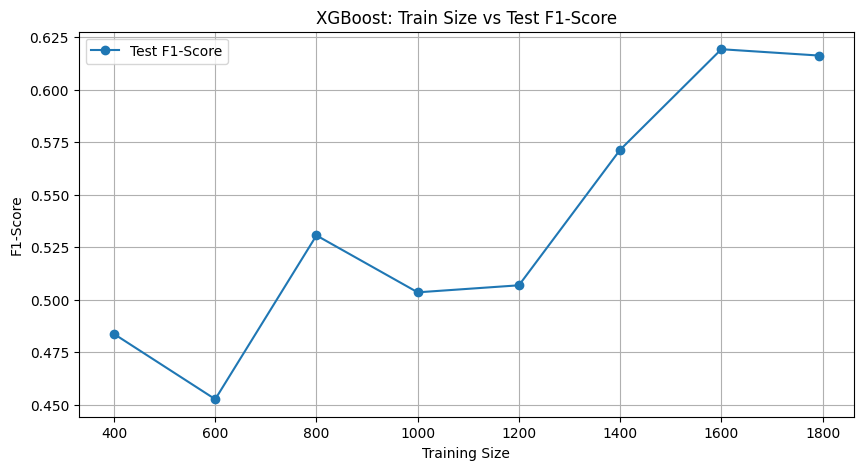

In [103]:

# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("XGBoost: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in xgb_size_results], [r['test_f1'] for r in xgb_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("xgb_train_size_vs_f1.png")
plt.show()

In [ ]:
# ============================================================
# Explainable Boosting Machine (EBM)
# ============================================================

from interpret.glassbox import ExplainableBoostingClassifier

feature_names = marketing_df.drop(columns=['AcceptedAny']).columns.tolist()

X = marketing_df.drop(columns=['AcceptedAny']).values
y = marketing_df['AcceptedAny'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# EBM converts float labels to strings internally, breaking sklearn's f1 scorer
# (pos_label=1 not in ['0.0','1.0']), so cast to int explicitly
y_train_int = y_train.astype(int)
y_test_int  = y_test.astype(int)

# --- Hyperparameter tuning via GridSearchCV ---
param_grid = {
    'max_bins': [48, 64, 80],
    'interactions': [20, 25, 30, 35, 40],
}

grid_search = GridSearchCV(
    ExplainableBoostingClassifier(feature_names=feature_names, random_state=RANDOM_SEED),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train_int)
end_time = time.time()

best_ebm = grid_search.best_params_
best_ebm_cv_f1 = grid_search.best_score_
print(f"Best Config: {best_ebm}, CV F1: {best_ebm_cv_f1:.4f}")
print(f"Grid search time: {end_time - start_time:.4f}s")

print("\n{:<12} {:<15} {:<10}".format("max_bins", "interactions", "CV F1"))
for mean, params in zip(grid_search.cv_results_['mean_test_score'],
                        grid_search.cv_results_['params']):
    print("{:<12} {:<15} {:<10.4f}".format(
        params['max_bins'], params['interactions'], mean))

Best Config: {'interactions': 30, 'max_bins': 64}, CV F1: 0.5969
Grid search time: 1218.9910s

max_bins     interactions    CV F1     
48           20              0.5779    
64           20              0.5708    
80           20              0.5655    
48           25              0.5755    
64           25              0.5882    
80           25              0.5847    
48           30              0.5836    
64           30              0.5969    
80           30              0.5873    


In [105]:
# --- Evaluate best EBM on test set ---
ebm_model = ExplainableBoostingClassifier(
    feature_names=feature_names,
    max_bins=best_ebm['max_bins'],
    interactions=best_ebm['interactions'],
    random_state=RANDOM_SEED
)

start_time = time.time()
ebm_model.fit(X_train_scaled, y_train_int)
end_time = time.time()
ebm_training_time = end_time - start_time

y_test_pred = ebm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test_int, y_test_pred)
f1 = f1_score(y_test_int, y_test_pred)
precision = precision_score(y_test_int, y_test_pred)
recall = recall_score(y_test_int, y_test_pred)

print(f"\nEBM (max_bins={best_ebm['max_bins']}, interactions={best_ebm['interactions']}) Test Results:")
print(f"Accuracy:  {accuracy:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"Training Time: {ebm_training_time:.4f} seconds")


EBM (max_bins=64, interactions=30) Test Results:
Accuracy:  0.87
F1-Score:  0.62
Precision: 0.76
Recall:    0.52
Training Time: 50.3043 seconds


Train Size: 400 | Train Error: 0.0975 | Test Error: 0.1674 | Test F1: 0.4444
Train Size: 800 | Train Error: 0.0825 | Test Error: 0.1585 | Test F1: 0.4965
Train Size: 1200 | Train Error: 0.1050 | Test Error: 0.1607 | Test F1: 0.4930
Train Size: 1600 | Train Error: 0.0575 | Test Error: 0.1540 | Test F1: 0.5430
Train Size: 1792 | Train Error: 0.0569 | Test Error: 0.1339 | Test F1: 0.6154


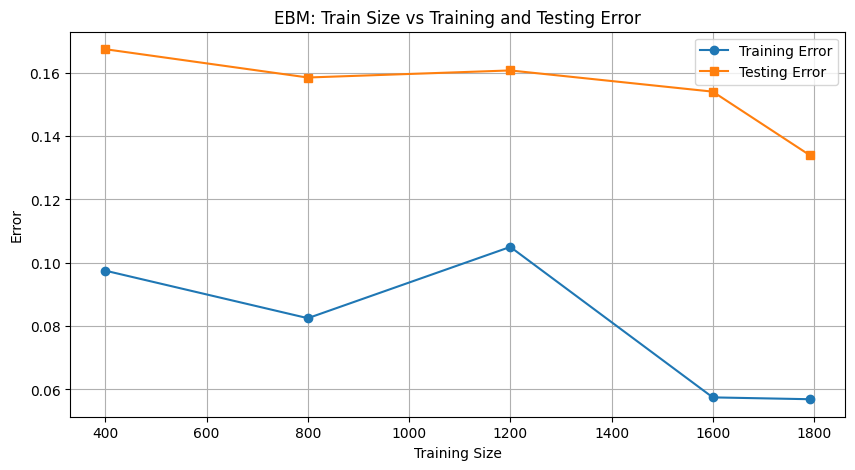

In [109]:
# --- Train size vs error ---
train_sizes = [400, 800, 1200, 1600, 1792]
ebm_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train_int[:size]

    ebm_model_tmp = ExplainableBoostingClassifier(
        feature_names=feature_names,
        max_bins=best_ebm['max_bins'],
        interactions=best_ebm['interactions'],
        random_state=RANDOM_SEED
    )
    ebm_model_tmp.fit(X_train_subset, y_train_subset)

    y_train_pred = ebm_model_tmp.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = ebm_model_tmp.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test_int, y_test_pred)
    test_f1 = f1_score(y_test_int, y_test_pred)

    ebm_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

ebm_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in ebm_size_results])

plt.figure(figsize=(10, 5))
plt.title("EBM: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(ebm_size_results_arr[:, 0], ebm_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(ebm_size_results_arr[:, 0], ebm_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("ebm_train_size_vs_error.png")
plt.show()

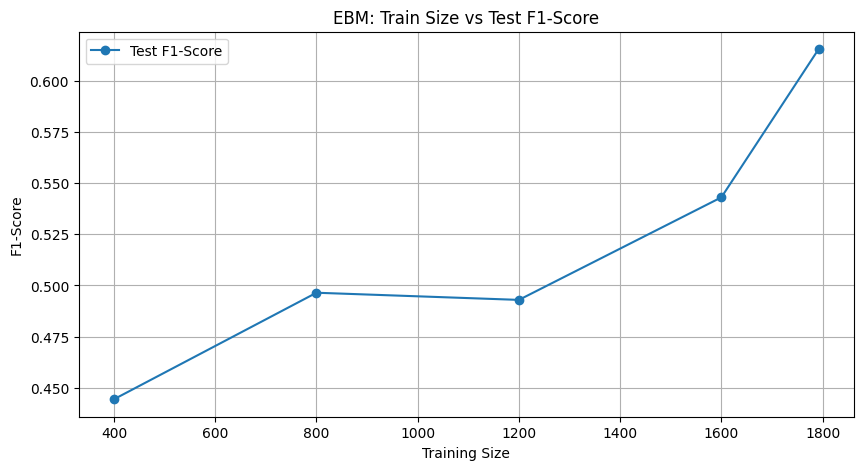

In [110]:
# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("EBM: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in ebm_size_results], [r['test_f1'] for r in ebm_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("ebm_train_size_vs_f1.png")
plt.show()

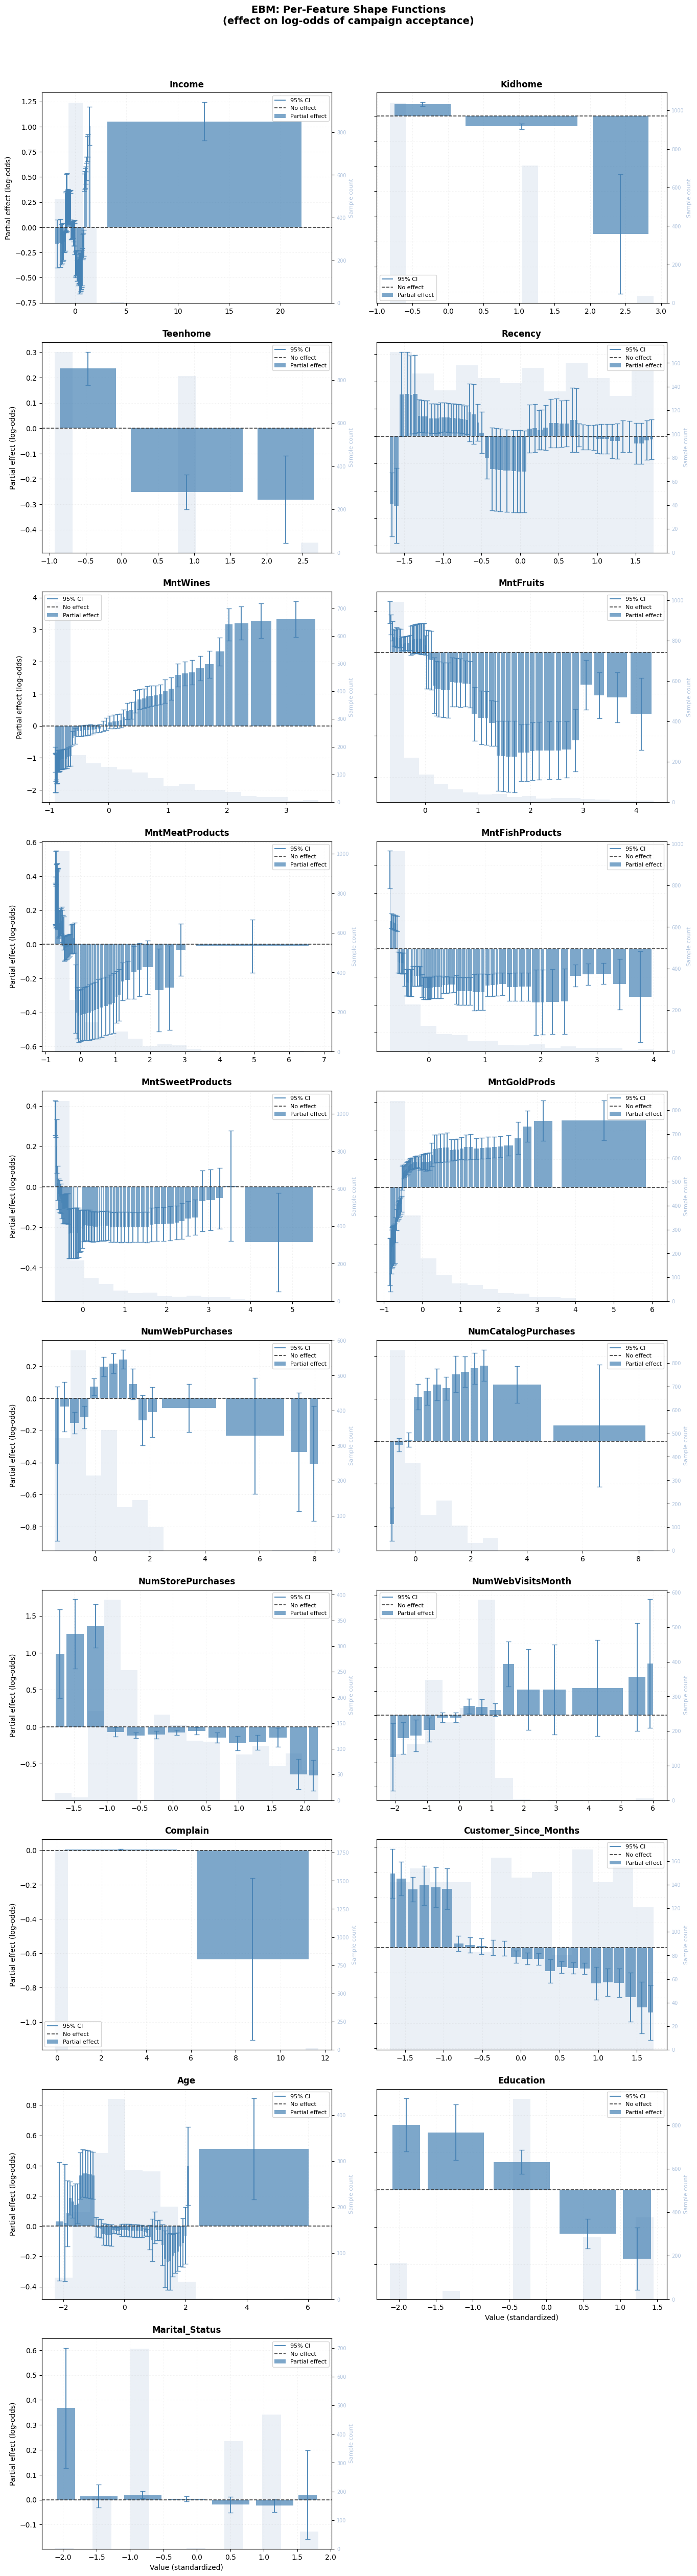

In [111]:
# --- Per-feature shape functions ---
# EBM decomposes predictions as f(X) = β₀ + f₁(x₁) + f₂(x₂) + ... + fₙ(xₙ),
# identical in structure to a GAM but learned via boosting rather than spline fitting.
# explain_global() exposes the per-feature shape functions and confidence bounds directly.

ebm_global = ebm_model.explain_global()

# Only keep main-effect terms (no interactions) whose data dict has the expected keys
main_effect_indices = [
    i for i, name in enumerate(ebm_global.data()['names'])
    if ' x ' not in name
    and 'names' in ebm_global.data(i)
    and 'scores' in ebm_global.data(i)
]

n_features = len(main_effect_indices)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for plot_idx, term_idx in enumerate(main_effect_indices):
    ax = axes[plot_idx]
    data = ebm_global.data(term_idx)
    feat_name = ebm_global.data()['names'][term_idx]

    bin_edges = np.array(data['names'], dtype=float)   # n+1 bin edges
    scores    = np.array(data['scores'],       dtype=float)   # n shape function values
    upper     = np.array(data['upper_bounds'], dtype=float)
    lower     = np.array(data['lower_bounds'], dtype=float)

    x_left  = bin_edges[:-1]
    x_right = bin_edges[1:]
    x_mid   = (x_left + x_right) / 2
    widths  = x_right - x_left

    # Density histogram as a faded background (secondary y-axis)
    dens_edges  = np.array(data['density']['names'], dtype=float)
    dens_counts = np.array(data['density']['scores'], dtype=float)
    ax2 = ax.twinx()
    ax2.bar(dens_edges[:-1], dens_counts, width=dens_edges[1:] - dens_edges[:-1],
            align='edge', color='lightsteelblue', alpha=0.25, zorder=0)
    ax2.set_ylabel("Sample count", fontsize=8, color='lightsteelblue')
    ax2.tick_params(axis='y', labelcolor='lightsteelblue', labelsize=7)

    # Shape function bars
    ax.bar(x_mid, scores, width=widths * 0.85,
           color='steelblue', alpha=0.7, label='Partial effect', zorder=2)

    # 95% confidence interval error bars
    ax.vlines(x_mid, lower, upper, color='steelblue', linewidth=1.5, alpha=0.9,
              label='95% CI', zorder=3)
    ax.plot(x_mid, upper, '_', color='steelblue', markersize=7, alpha=0.9, zorder=3)
    ax.plot(x_mid, lower, '_', color='steelblue', markersize=7, alpha=0.9, zorder=3)

    # Zero reference line
    ax.axhline(0, color='#333333', linestyle='--', linewidth=1.2,
               label='No effect', zorder=4)

    ax.set_title(feat_name, fontsize=12, fontweight='bold', pad=8)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    if plot_idx % n_cols == 0:
        ax.set_ylabel("Partial effect (log-odds)", fontsize=10)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    if plot_idx >= n_features - n_cols:
        ax.set_xlabel("Value (standardized)", fontsize=10)

    ax.grid(True, alpha=0.2, linestyle=':', zorder=1)
    ax.legend(fontsize=8, loc='best')

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("EBM: Per-Feature Shape Functions\n(effect on log-odds of campaign acceptance)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig("ebm_shape_functions.png", dpi=150, bbox_inches='tight')
plt.show()